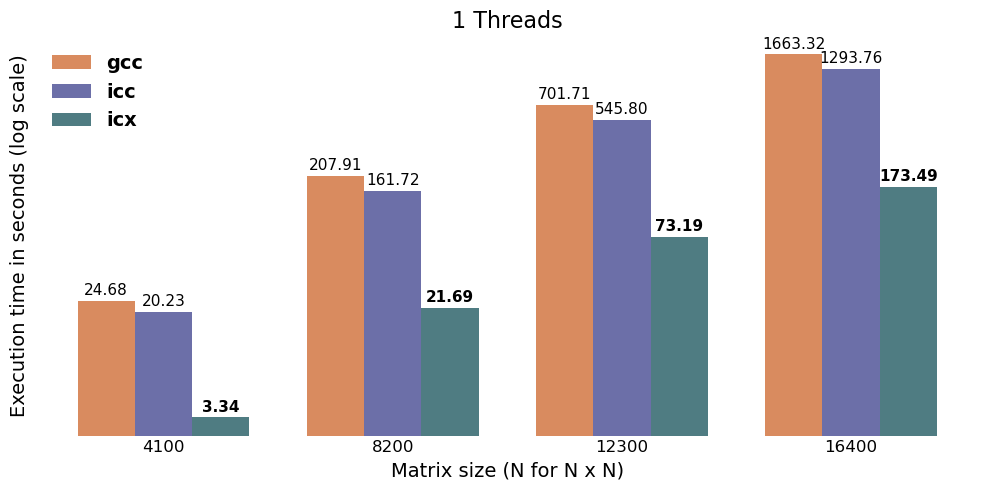

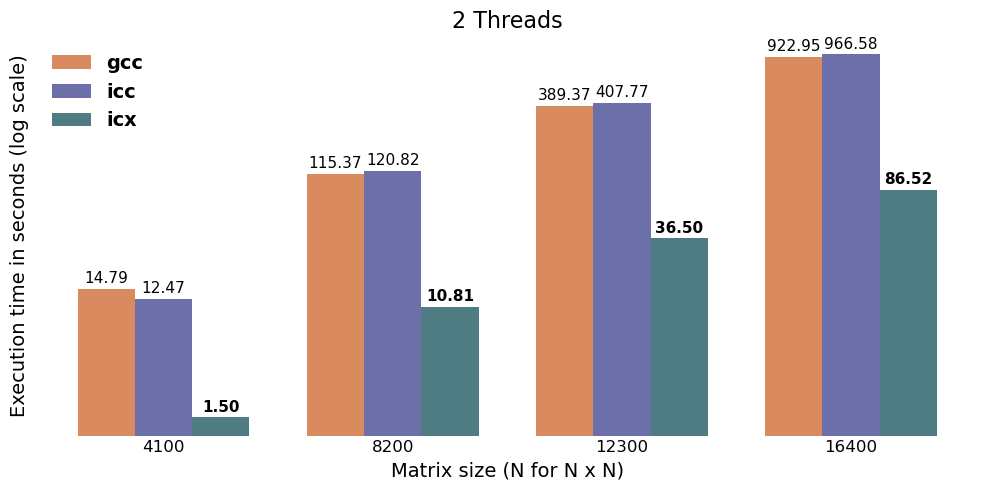

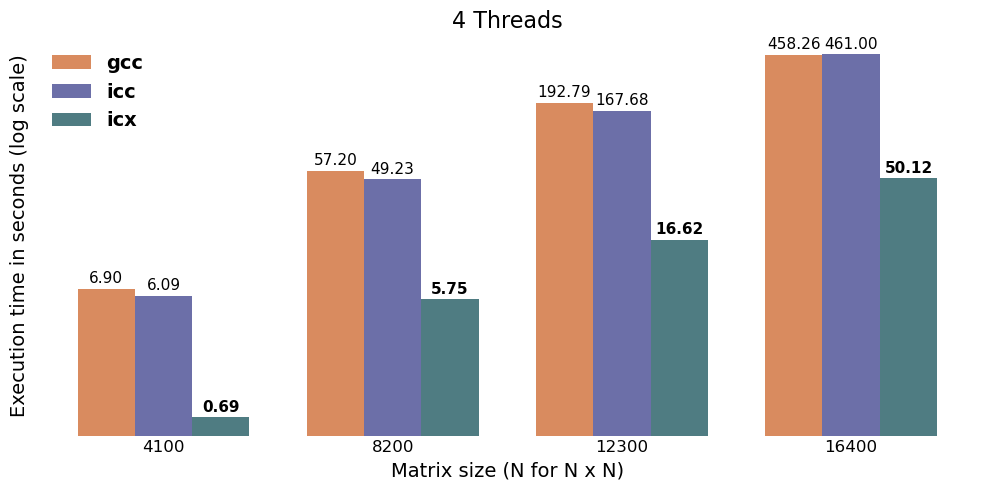

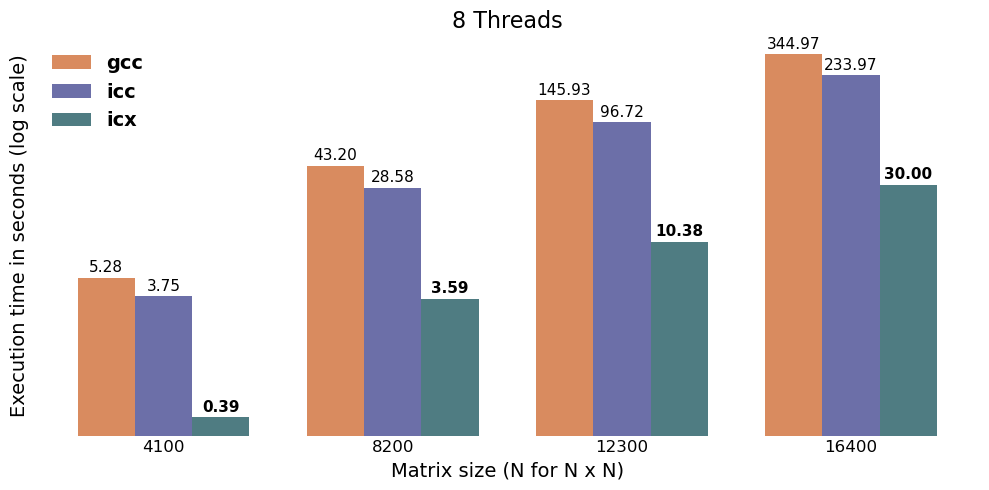

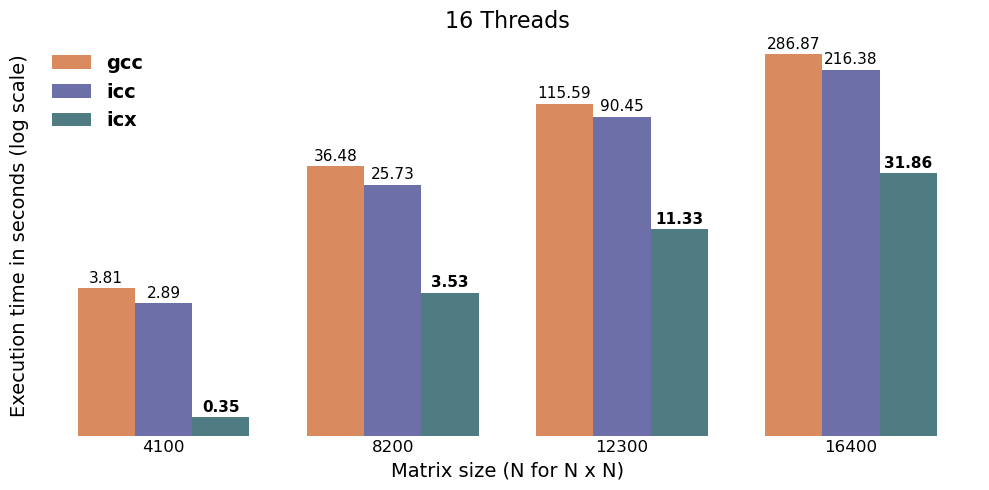

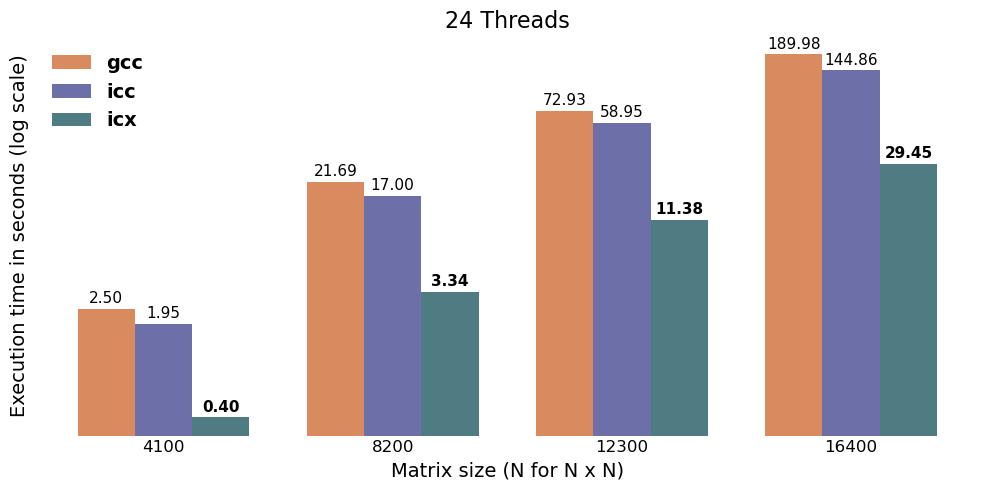

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("benchmark_results_omp_updated.csv")

# Custom color palette
colors = [
    "#D98B5F",  # warm orange
    "#6C6FA8",  # muted purple
    "#4F7C82",  # desaturated teal
]

selected_sizes = [4100, 8200, 12300, 16400]
thread_values = [1,2, 4, 8, 16, 24]

filtered = df[
    (df["Test"] == "omp-ikj") &
    (df["Compiler"].isin(["gcc", "icc", "icx"])) &
    (df["N"].isin(selected_sizes)) &
    (df["Threads/Ranks"].isin(thread_values))
].copy()

filtered = filtered.sort_values(["Threads/Ranks", "N", "Compiler"])

bar_width = 0.25
x = np.arange(len(selected_sizes))

for threads in thread_values:
    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    thread_df = filtered[filtered["Threads/Ranks"] == threads]

    gcc_times = []
    icc_times = []
    icx_times = []

    for n in selected_sizes:
        gcc_row = thread_df[(thread_df["Compiler"] == "gcc") & (thread_df["N"] == n)]
        icc_row = thread_df[(thread_df["Compiler"] == "icc") & (thread_df["N"] == n)]
        icx_row = thread_df[(thread_df["Compiler"] == "icx") & (thread_df["N"] == n)]

        gcc_times.append(gcc_row["Time_s"].iloc[0] if not gcc_row.empty else np.nan)
        icc_times.append(icc_row["Time_s"].iloc[0] if not icc_row.empty else np.nan)
        icx_times.append(icx_row["Time_s"].iloc[0] if not icx_row.empty else np.nan)

    bars_gcc = ax.bar(
        x - bar_width,
        gcc_times,
        width=bar_width,
        label="gcc",
        color=colors[0],
        edgecolor="none"
    )

    bars_icc = ax.bar(
        x,
        icc_times,
        width=bar_width,
        label="icc",
        color=colors[1],
        edgecolor="none"
    )

    bars_icx = ax.bar(
        x + bar_width,
        icx_times,
        width=bar_width,
        label="icx",
        color=colors[2],
        edgecolor="none"
    )

    # Log scale on Y axis
    ax.set_yscale("log")

    # Titles and labels
    ax.set_title(f"{threads} Threads", fontsize=16)
    ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
    ax.set_ylabel("Execution time in seconds (log scale)", fontsize=14)

    # X ticks
    ax.set_xticks(x)
    ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

    # Remove everything on Y axis except the label
    ax.set_yticks([])
    ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)

    # Remove black axis lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Remove X tick marks but keep labels
    ax.tick_params(axis="x", length=0)

    # Remove grid
    ax.grid(False)

    # Legend
    ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})

    # Add value labels and bold the minimum value in each matrix-size group
    for i in range(len(selected_sizes)):
        values = [gcc_times[i], icc_times[i], icx_times[i]]
        min_value = np.nanmin(values)

        current_bars = [bars_gcc[i], bars_icc[i], bars_icx[i]]

        for bar, value in zip(current_bars, values):
            if not np.isnan(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value * 1.05,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold" if value == min_value else "normal"
                )

    plt.tight_layout()
    plt.show()

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# =========================================================
# 1) DATA PREP
# =========================================================
def prepare_benchmark_df(frame: pd.DataFrame) -> pd.DataFrame:
    df = frame.copy()

    df = df.rename(columns={
        "CPU": "cpu",
        "Compiler": "compiler",
        "Test": "test",
        "N": "n",
        "Align": "align",
        "Restrict": "restrict",
        "Threads/Ranks": "threads",
        "TileSize": "tile_size",
        "Time_s": "time_s",
    })

    df["compiler"] = df["compiler"].astype(str).str.strip().str.lower()
    df["test"] = df["test"].astype(str).str.strip()
    df["n"] = pd.to_numeric(df["n"], errors="coerce")
    df["threads"] = pd.to_numeric(df["threads"], errors="coerce")
    df["tile_size"] = pd.to_numeric(df["tile_size"], errors="coerce")
    df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")

    return df


# =========================================================
# 2) FLEXIBLE GREEN COLORMAP
# =========================================================
def make_green_cmap(anchor_colors=None, n_colors=256):
    if anchor_colors is None:
        anchor_colors = [
            "#F4FBF4",
            "#8DB28D",
            "#9BC79D",
            "#4C8C4E",
            "#1D381E"
        ]
    return LinearSegmentedColormap.from_list("flex_green", anchor_colors, N=n_colors)


# =========================================================
# 3) BUILD PIVOT
# =========================================================
def build_tile_pivot(
    frame: pd.DataFrame,
    compiler: str,
    matrix_size: int,
    test_filter="tile",
    tile_order=None,    
    thread_order=None,
):
    df = prepare_benchmark_df(frame)

    sub = df[
        (df["compiler"] == compiler.lower()) &
        (df["n"] == matrix_size) &
        (df["test"].str.contains(test_filter, case=False, na=False)) &
        (df["tile_size"].notna()) &
        (df["threads"].notna()) &
        (df["time_s"].notna())
    ].copy()

    if sub.empty:
        return None

    if tile_order is None:
        tile_order = sorted(sub["tile_size"].unique())
    if thread_order is None:
        thread_order = sorted(sub["threads"].unique())

    pivot = (
        sub.pivot_table(
            index="tile_size",
            columns="threads",
            values="time_s",
            aggfunc="min"
        )
        .reindex(index=tile_order, columns=thread_order)
    )

    return pivot


def apply_minimal_heatmap_style(ax, show_ylabels=True):
    # via le linee nere (spines)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # via i tick "trattini" (major+minor), lasciando le etichette
    ax.tick_params(axis="both", which="both", length=0)

    # y labels solo a sinistra
    if not show_ylabels:
        ax.set_yticks([])
        ax.set_yticklabels([])

    # griglia minimal (se vuoi tenerla)
    ax.set_axisbelow(True)
    #ax.grid(which="minor", linestyle="-", linewidth=0.5, alpha=0.15)

# =========================================================
# 4) MAIN FUNCTION
# =========================================================
def plot_tile_compare_pair(
    frame: pd.DataFrame,
    matrix_size: int,
    compilers=("icc", "icx"),
    test_filter="tile",
    anchor_colors=None,
    n_colors=256,
    highlight="min",   # "max" oppure "min"
    figsize=(10.5, 4.6),
    annotate=True
):
    df = prepare_benchmark_df(frame)
    comp_a, comp_b = compilers

    sub_all = df[
        (df["compiler"].isin([comp_a.lower(), comp_b.lower()])) &
        (df["n"] == matrix_size) &
        (df["test"].str.contains(test_filter, case=False, na=False)) &
        (df["tile_size"].notna()) &
        (df["threads"].notna())
    ].copy()

    if sub_all.empty:
        print(f"Nessun dato trovato per N={matrix_size}, compilers={compilers}, test_filter='{test_filter}'")
        print("Compilers disponibili:", sorted(df["compiler"].dropna().unique()))
        print("Tests disponibili:", sorted(df["test"].dropna().unique()))
        print("N disponibili:", sorted(df["n"].dropna().unique()))
        return

    tile_order = sorted(sub_all["tile_size"].unique())
    thread_order = sorted(sub_all["threads"].unique())

    pivot_a = build_tile_pivot(
        df, compiler=comp_a, matrix_size=matrix_size,
        test_filter=test_filter, tile_order=tile_order, thread_order=thread_order
    )
    pivot_b = build_tile_pivot(
        df, compiler=comp_b, matrix_size=matrix_size,
        test_filter=test_filter, tile_order=tile_order, thread_order=thread_order
    )

    if pivot_a is None and pivot_b is None:
        print(f"Nessun dato utile per N={matrix_size}")
        return

    if pivot_a is None:
        pivot_a = pd.DataFrame(index=tile_order, columns=thread_order, dtype=float)
    if pivot_b is None:
        pivot_b = pd.DataFrame(index=tile_order, columns=thread_order, dtype=float)

    vals = np.concatenate([
        pivot_a.to_numpy(dtype=float).ravel(),
        pivot_b.to_numpy(dtype=float).ravel()
    ])
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        print(f"Nessun valore numerico disponibile per N={matrix_size}")
        return

    cmap = make_green_cmap(anchor_colors=anchor_colors, n_colors=n_colors)
    norm = Normalize(vmin=float(vals.min()), vmax=float(vals.max()))

    A = pivot_a.to_numpy(dtype=float)
    B = pivot_b.to_numpy(dtype=float)

    bold_a = np.zeros_like(A, dtype=bool)
    bold_b = np.zeros_like(B, dtype=bool)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            a = A[i, j]
            b = B[i, j]

            if np.isfinite(a) and np.isfinite(b):
                if highlight == "max":
                    if a > b:
                        bold_a[i, j] = True
                    elif b > a:
                        bold_b[i, j] = True
                    else:
                        bold_a[i, j] = True
                        bold_b[i, j] = True
                else:  # min
                    if a < b:
                        bold_a[i, j] = True
                    elif b < a:
                        bold_b[i, j] = True
                    else:
                        bold_a[i, j] = True
                        bold_b[i, j] = True
            elif np.isfinite(a):
                bold_a[i, j] = True
            elif np.isfinite(b):
                bold_b[i, j] = True

    fig, axes = plt.subplots(1, 2, figsize=figsize, squeeze=False)
    axes = axes[0]

    im = None

    for k, (ax, pivot, bold_mask, comp) in enumerate(zip(
        axes,
        [pivot_a, pivot_b],
        [bold_a, bold_b],
        [comp_a, comp_b]
    )):
        data = np.ma.masked_invalid(pivot.to_numpy(dtype=float))
        im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm)
        ax.invert_yaxis()

        ax.set_title(f"{comp.upper()}", fontsize=14)
        
        # etichetta unica centrata
        fig.supxlabel("Number of threads", fontsize=11, y=0.04)

        # più spazio sotto per la supxlabel
        fig.subplots_adjust(left=0.08, right=0.86, top=0.80, bottom=0.18, wspace=0.06)

        # y-axis solo a sinistra
        if k == 0:
            ax.set_ylabel("Tile size", fontsize=11)
            ax.set_yticks(range(len(tile_order)))
            ax.set_yticklabels([int(x) for x in tile_order], fontsize=10)
        else:
            ax.set_ylabel("")
            ax.set_yticks([])
            ax.set_yticklabels([])

        ax.set_xticks(range(len(thread_order)))
        ax.set_xticklabels([int(x) for x in thread_order], fontsize=10)

       # griglia leggera (celle)
        ax.set_xticks(np.arange(-0.5, len(thread_order), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(tile_order), 1), minor=True)

        # applico stile minimal
        apply_minimal_heatmap_style(ax, show_ylabels=(k == 0))
        #ax.grid(which="minor", linestyle="-", linewidth=0.5, alpha=0.20)
        ax.tick_params(which="minor", bottom=False, left=False)
        
        # Remove grid
        ax.grid(False)
        
        if annotate:
            midpoint = (norm.vmin + norm.vmax) / 2.0

            for i in range(pivot.shape[0]):
                for j in range(pivot.shape[1]):
                    value = pivot.iloc[i, j]
                    if pd.notna(value):
                        color = "white" if value > midpoint else "black"
                        weight = "bold" if bold_mask[i, j] else "normal"

                        ax.text(
                            j, i, f"{value:.2f}",
                            ha="center", va="center",
                            fontsize=10,
                            color=color,
                            fontweight=weight
                        )

    fig.suptitle(f"Matrix size: {matrix_size} x {matrix_size}", fontsize=13, y=0.96)
    

    # più vicini e spazio a destra per la colorbar
    fig.subplots_adjust(left=0.08, right=0.86, top=0.80, bottom=0.14, wspace=0.06)

    # UNA sola colorbar, dedicata
    cax = fig.add_axes([0.9, 0.2, 0.02, 0.60])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Execution time in seconds", fontsize=11, labelpad=14)

    plt.show()

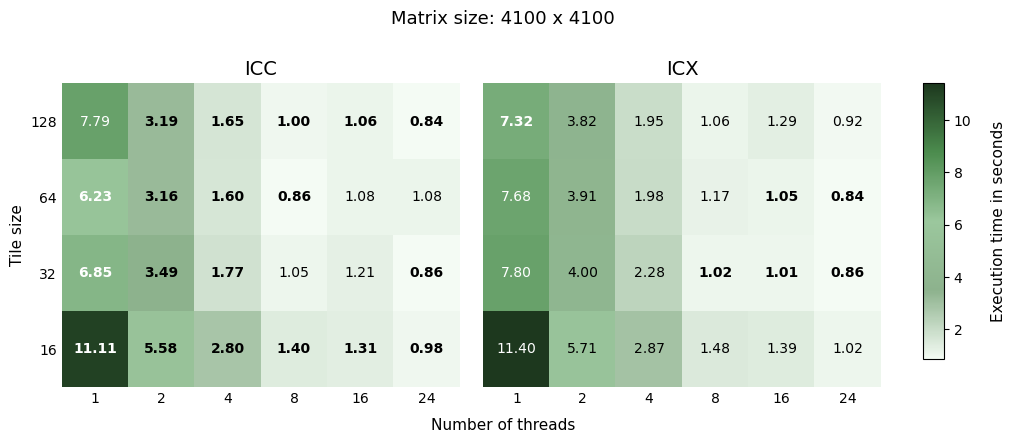

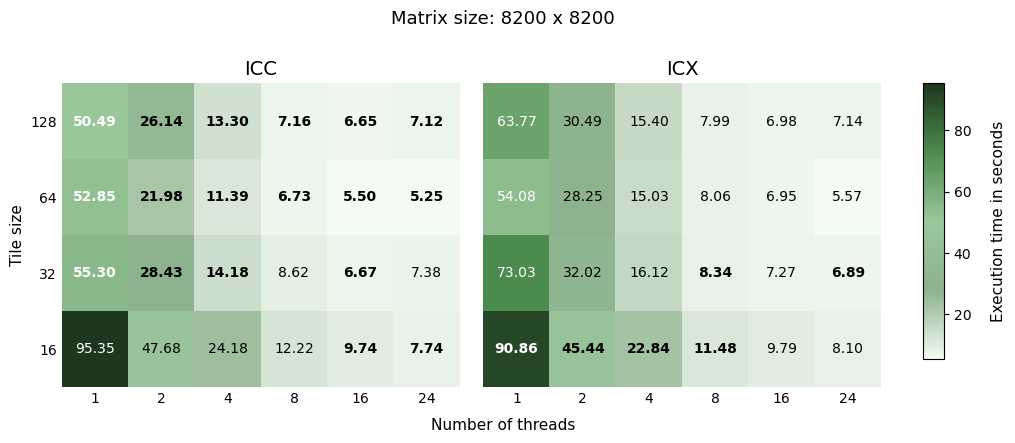

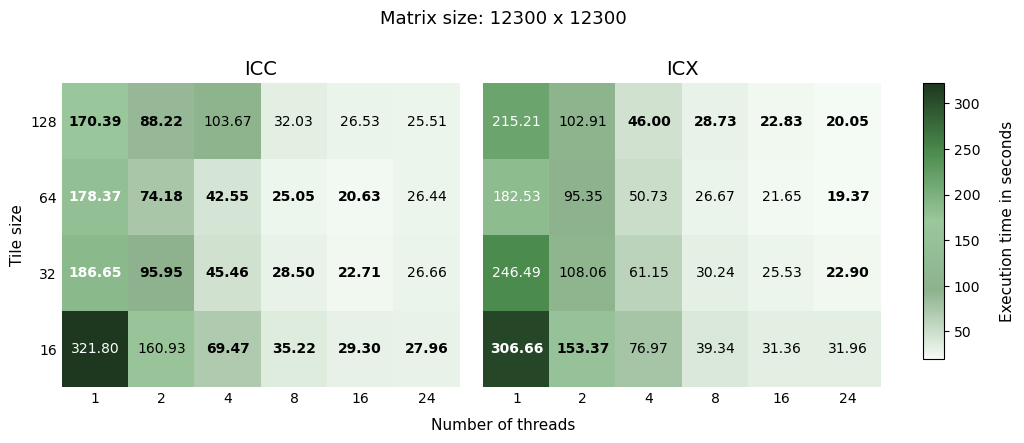

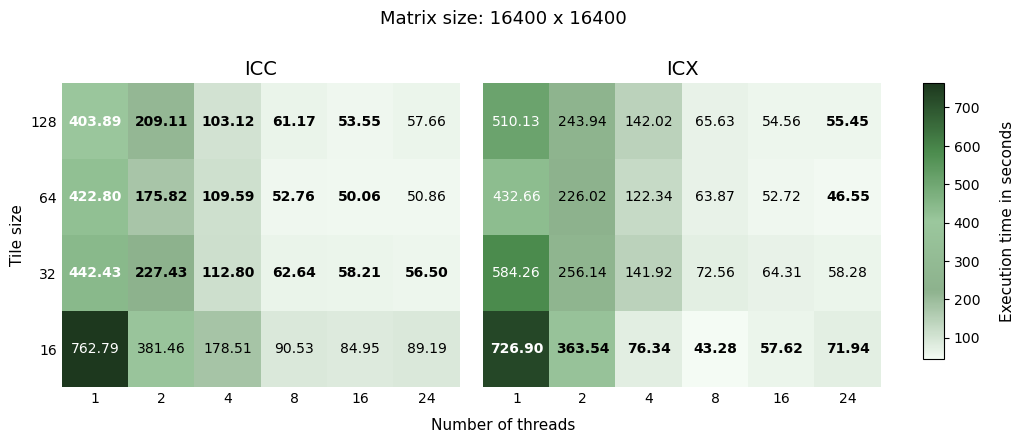

In [14]:
plot_tile_compare_pair(df, matrix_size=4100, compilers=("icc", "icx"), test_filter="tile")
plot_tile_compare_pair(df, matrix_size=8200, compilers=("icc", "icx"), test_filter="tile")
plot_tile_compare_pair(df, matrix_size=12300, compilers=("icc", "icx"), test_filter="tile")
plot_tile_compare_pair(df, matrix_size=16400, compilers=("icc", "icx"), test_filter="tile")

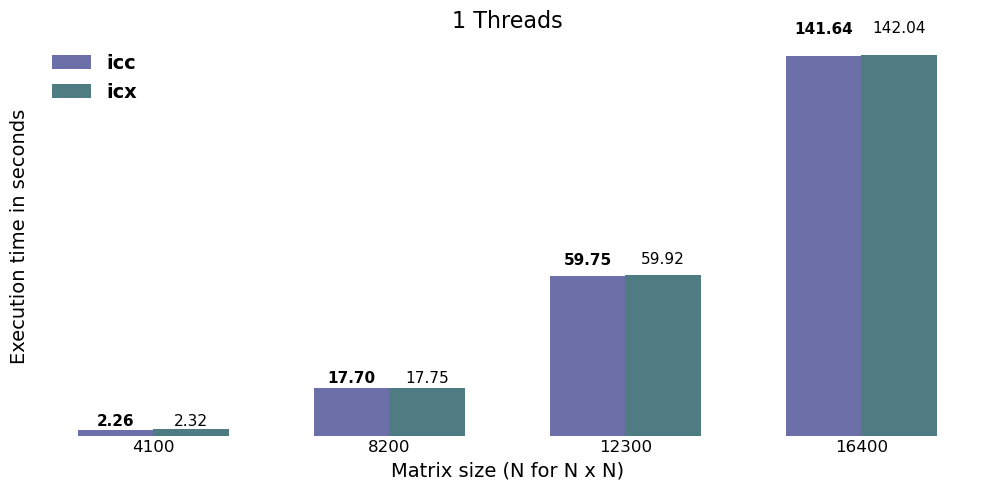

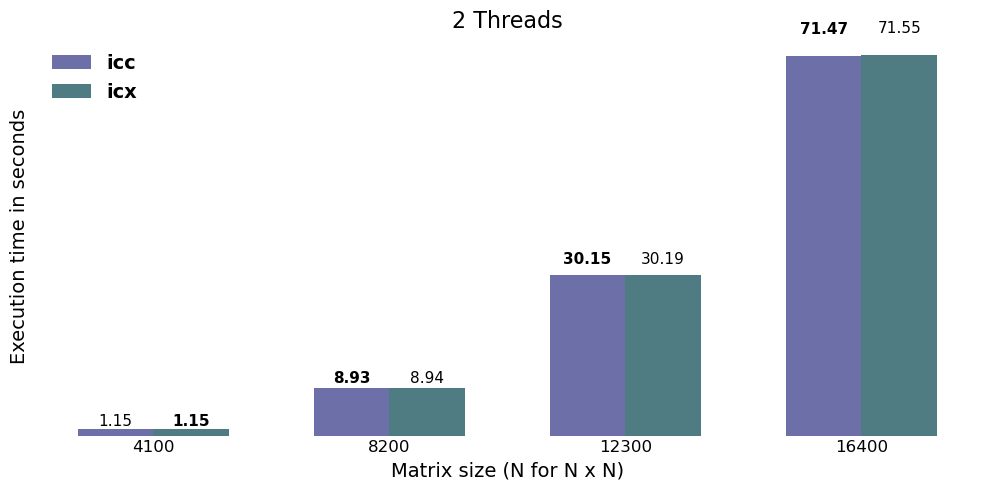

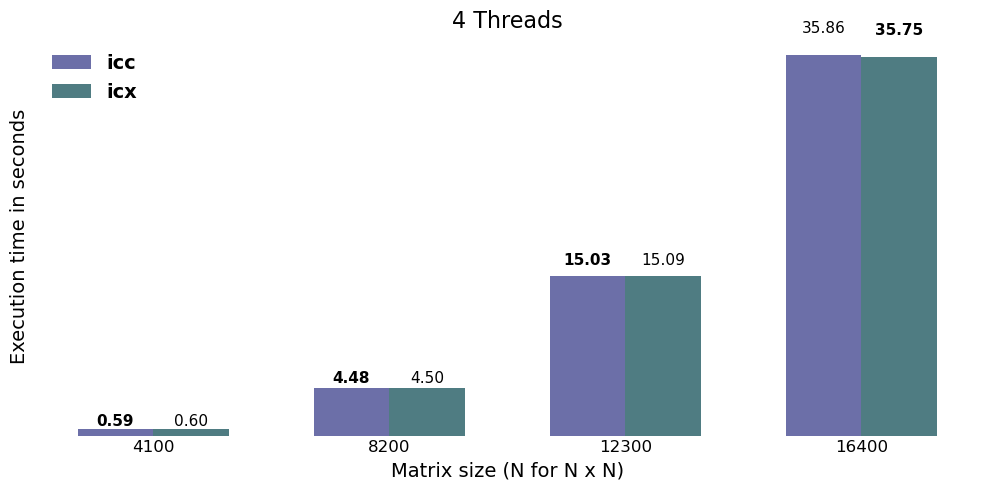

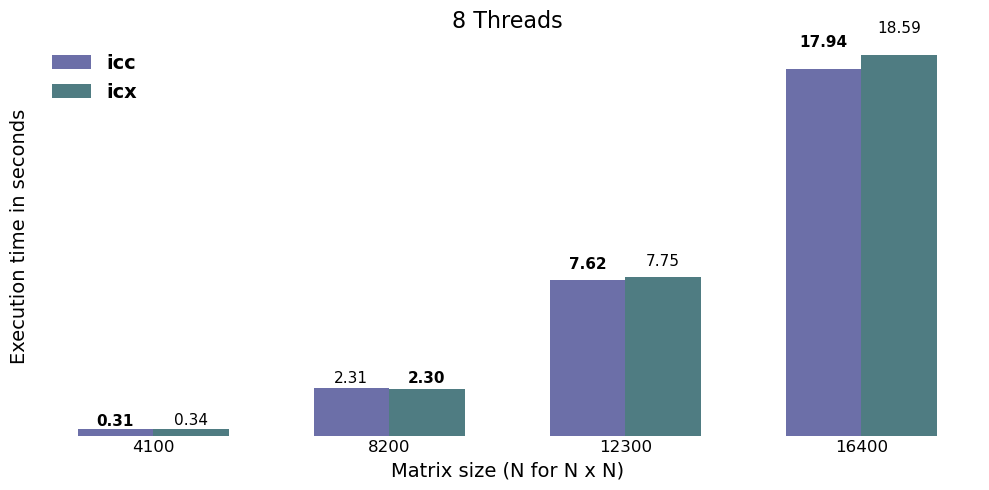

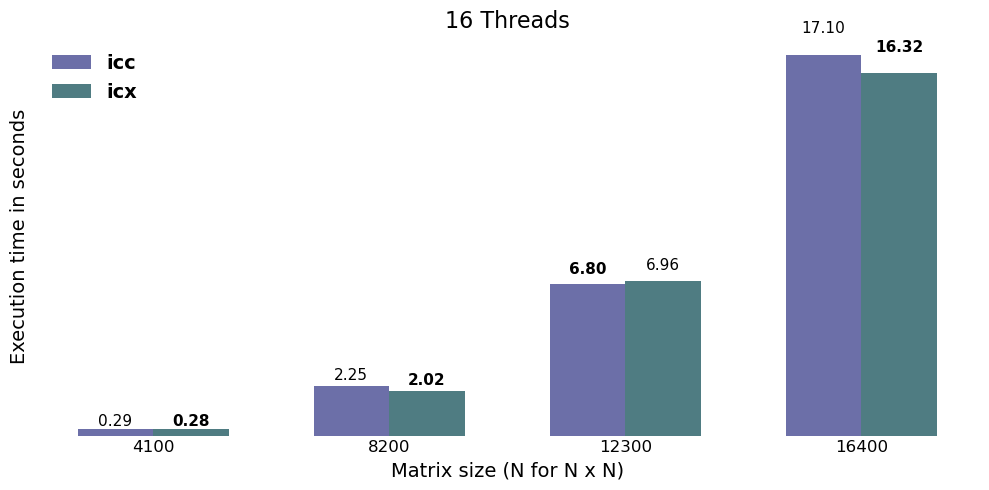

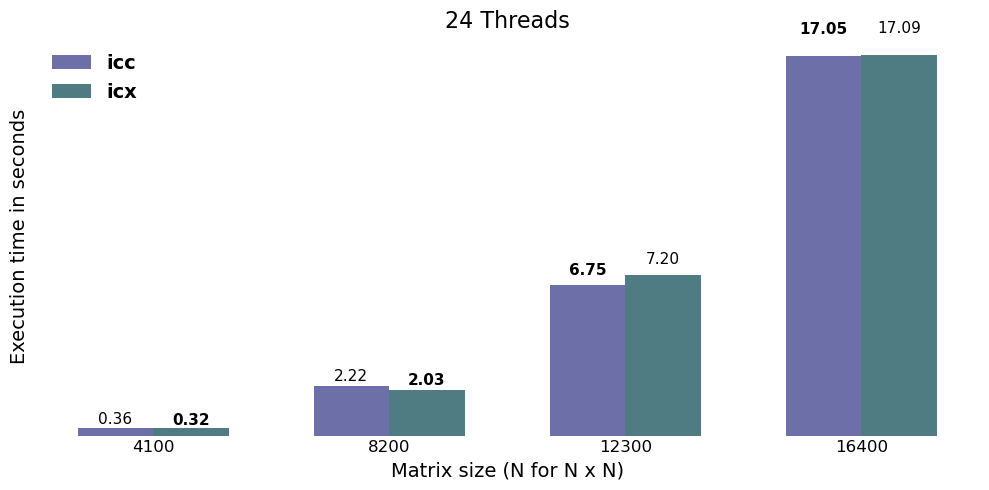

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("benchmark_results_omp_updated.csv")

# Custom color palette
colors = [
    "#6C6FA8",  # icc
    "#4F7C82",  # icx
]

selected_sizes = [4100, 8200, 12300, 16400]


filtered = df[
    (df["Test"] == "mkl-omp") &
    (df["Compiler"].isin(["icc", "icx"])) &
    (df["N"].isin(selected_sizes)) &
    (df["Threads/Ranks"].isin(thread_values))
].copy()

filtered = filtered.sort_values(["Threads/Ranks", "N", "Compiler"])

bar_width = 0.32
x = np.arange(len(selected_sizes))

for threads in thread_values:
    fig, ax = plt.subplots(figsize=(10, 5))

    thread_df = filtered[filtered["Threads/Ranks"] == threads]

    icc_times = []
    icx_times = []

    for n in selected_sizes:
        icc_row = thread_df[(thread_df["Compiler"] == "icc") & (thread_df["N"] == n)]
        icx_row = thread_df[(thread_df["Compiler"] == "icx") & (thread_df["N"] == n)]

        icc_times.append(icc_row["Time_s"].iloc[0] if not icc_row.empty else np.nan)
        icx_times.append(icx_row["Time_s"].iloc[0] if not icx_row.empty else np.nan)

    # Barre affiancate
    bars_icc = ax.bar(
        x,
        icc_times,
        width=bar_width,
        label="icc",
        color=colors[0],
        edgecolor="none"
    )

    bars_icx = ax.bar(
        x + bar_width,
        icx_times,
        width=bar_width,
        label="icx",
        color=colors[1],
        edgecolor="none"
    )

    # Titoli e labels
    ax.set_title(f"{threads} Threads", fontsize=16)
    ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)
    ax.set_ylabel("Execution time in seconds", fontsize=14)

    # X ticks centrati sul gruppo di 2 barre
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels([str(n) for n in selected_sizes], fontsize=12)

    # Remove everything on Y axis except the label
    ax.set_yticks([])
    ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)

    # Remove black axis lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Remove X tick marks but keep labels
    ax.tick_params(axis="x", length=0)

    # Remove grid
    ax.grid(False)

    # Legend
    ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})

    # Add value labels centered INSIDE each bar
    # Bold the minimum value between icc and icx for each matrix size
    for i in range(len(selected_sizes)):
        values = [icc_times[i], icx_times[i]]
        min_value = np.nanmin(values)

        current_bars = [bars_icc[i], bars_icx[i]]

        for bar, value in zip(current_bars, values):
            if not np.isnan(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value * 1.05,
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold" if value == min_value else "normal"
                )

    plt.tight_layout()
    plt.show()

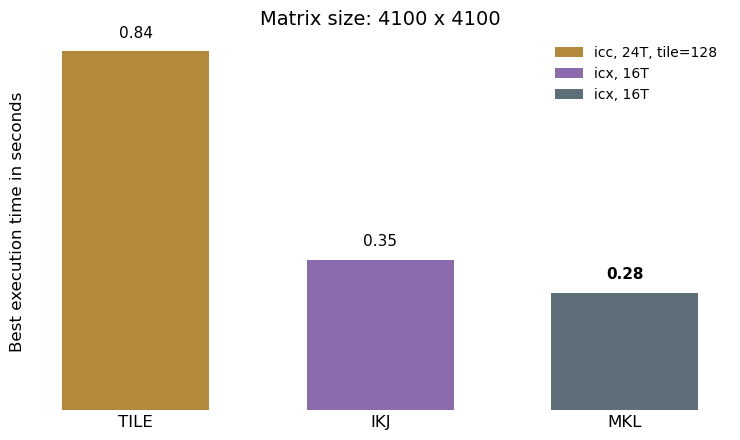

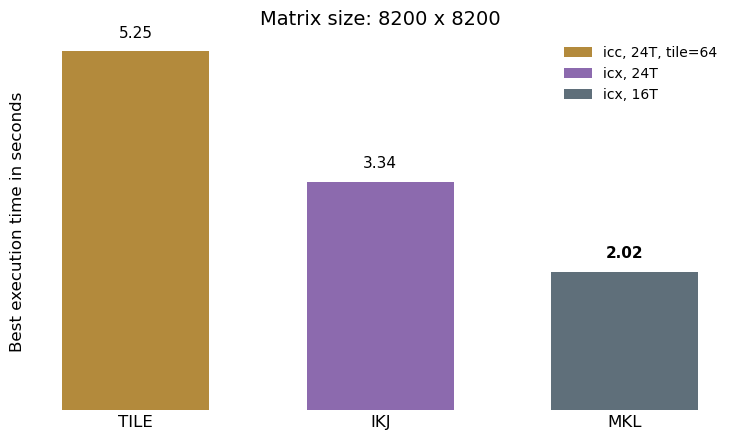

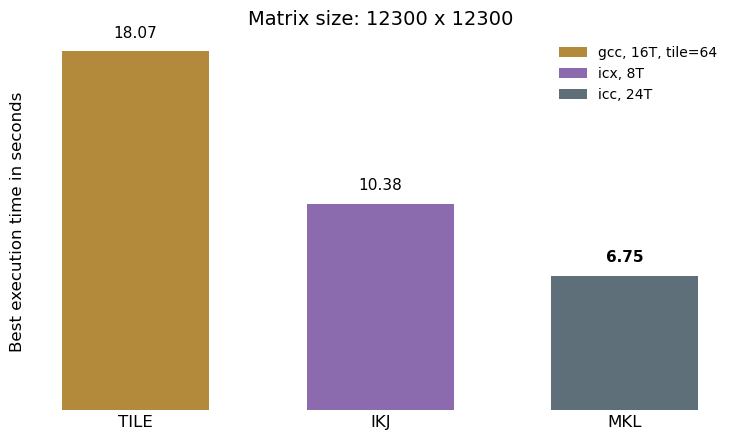

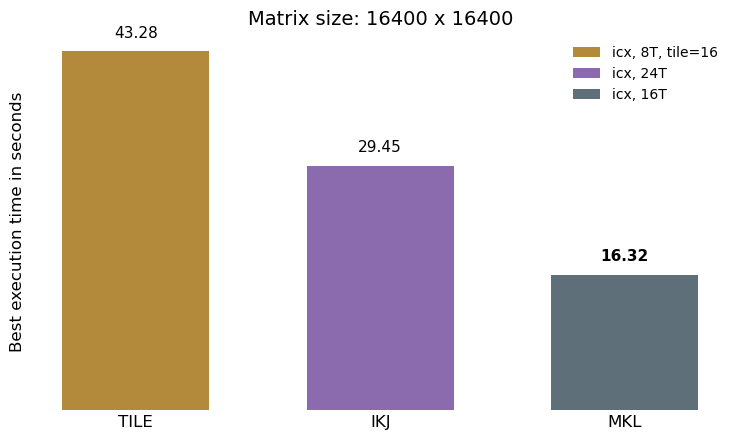

In [16]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- input ---
df = pd.read_csv("benchmark_results_omp_updated.csv")

selected_sizes = [4100, 8200, 12300, 16400]

# --- pulizia tipi ---
df["Compiler"] = df["Compiler"].astype(str).str.strip().str.lower()
df["Test"] = df["Test"].astype(str).str.strip().str.lower()
df["N"] = pd.to_numeric(df["N"], errors="coerce")
df["Threads/Ranks"] = pd.to_numeric(df["Threads/Ranks"], errors="coerce")
df["Time_s"] = pd.to_numeric(df["Time_s"], errors="coerce")
df["TileSize_num"] = pd.to_numeric(df["TileSize"], errors="coerce")  # "-" -> NaN

# --- classificazione approccio ---
def classify_approach(row) -> str:
    t = row["Test"]
    tile_num = row["TileSize_num"]
    if "mkl" in t:
        return "mkl"
    if ("tile" in t) or np.isfinite(tile_num):
        return "tile"
    if "ikj" in t:
        return "ikj"
    return "other"

df["approach"] = df.apply(classify_approach, axis=1)

# --- colori (3 barre) ---
colors = {
    "ikj":  "#8C6AAE",  # purple
    "tile": "#B38A3C",  # green
    "mkl":  "#5F6F7A",  # teal
}

def best_row_per_approach(sub: pd.DataFrame):
    """
    Ritorna dict: approach -> (best_time, row_best)
    best_time = min Time_s su TUTTE le configurazioni (compiler/threads/tile)
    """
    out = {}
    for a in [ "tile", "ikj","mkl"]:
        tmp = sub[sub["approach"] == a].dropna(subset=["Time_s"])
        if tmp.empty:
            out[a] = (np.nan, None)
        else:
            idx = tmp["Time_s"].idxmin()
            out[a] = (float(tmp.loc[idx, "Time_s"]), tmp.loc[idx])
    return out

def format_cfg(row, approach):
    if row is None:
        return "no data"
    comp = row["Compiler"]
    th = int(row["Threads/Ranks"]) if pd.notna(row["Threads/Ranks"]) else None
    if approach == "tile":
        ts = int(row["TileSize_num"]) if pd.notna(row["TileSize_num"]) else None
        if th is not None and ts is not None:
            return f"{comp}, {th}T, tile={ts}"
        if th is not None:
            return f"{comp}, {th}T"
        return f"{comp}"
    else:
        if th is not None:
            return f"{comp}, {th}T"
        return f"{comp}"

def minimal_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)   # <-- linea asse X via

    # remove y numbers/ticks
    ax.set_yticks([])                        # <-- numeri asse Y via
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)
    ax.grid(False)

# --- 4 plot: uno per N ---
for N in selected_sizes:
    sub = df[df["N"] == N].copy()

    best = best_row_per_approach(sub)

    approaches = ["tile","ikj",  "mkl"]
    times = [best[a][0] for a in approaches]

    # best overall (tra i tre)
    finite_times = [(a, t) for a, t in zip(approaches, times) if np.isfinite(t)]
    if finite_times:
        best_overall_a, best_overall_t = min(finite_times, key=lambda x: x[1])
        title = f"Matrix size: {N} x {N}"
    else:
        title = f"Matrix size: {N} x {N} —  no data"

    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    x = np.arange(len(approaches))
    barlist = ax.bar(
        x, times,
        color=[colors[a] for a in approaches],
        edgecolor="none",
        width=0.60
    )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Best execution time in seconds", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([a.upper() for a in approaches], fontsize=12)

    # legenda con "migliore prestazione" (tempo + config)
    handles = []
    labels = []
    for a in approaches:
        t, row = best[a]
        if np.isfinite(t):
            labels.append(f"{format_cfg(row, a)}")
        else:
            labels.append(f"{a.upper()} — no data")
        handles.append(barlist[approaches.index(a)])

    ax.legend(handles, labels, frameon=False, loc="upper right", fontsize=10)

    # valori sopra le barre (come prima)
    # + grassetto sulla barra migliore (tempo MIN) tra i tre
    if finite_times:
        best_min_t = best_overall_t
    else:
        best_min_t = None

    # offset “robusto” per posizione testo
    max_t = np.nanmax(times) if np.any(np.isfinite(times)) else 0.0
    offset = max_t * 0.03 if max_t > 0 else 0.0

    for bar, a, t in zip(barlist, approaches, times):
        if np.isfinite(t):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                t + offset,
                f"{t:.2f}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold" if (best_min_t is not None and np.isclose(t, best_min_t)) else "normal"
            )

    minimal_style(ax)
    plt.tight_layout()
    plt.show()